# 05 — Deployment and demonstration

This notebook runs the service end to end: adaptive questionnaire, triage, guard rails,
traceability. It closes on what one decision costs, measured on the real endpoint.

No server is needed: the application is called directly, exactly as the hospital information
system would call it.

In [1]:
import json
import os
from pathlib import Path

os.environ["TRIAGE_BACKEND"] = "transformers"
os.environ["TRIAGE_API_KEY"] = "demonstration-key"
os.environ["TRIAGE_AUDIT_LOG"] = "demo_audit.jsonl"

from clinical_triage.config import PATHS

os.environ["TRIAGE_BASE_MODEL"] = str(PATHS.sft_merged)
os.environ["TRIAGE_ADAPTER_DIR"] = str(PATHS.dpo_adapter)
Path("demo_audit.jsonl").unlink(missing_ok=True)

HEADERS = {"X-API-Key": "demonstration-key"}
print("model served:", os.environ["TRIAGE_BASE_MODEL"])

modele servi : G:\Mon Drive\OC\Projet_14\triage\models\qwen3-1.7b-triage-sft-merged


The paths are **absolute**, and that detail matters: with relative ones, a notebook run from
`notebooks/` does not find the models and the application falls back silently to the base model.
The demonstration then runs on an unspecialised model with nothing to say so.

In [2]:
from fastapi.testclient import TestClient

from clinical_triage.serving.api import app

client = TestClient(app)
client.__enter__()
client.get("/health").json()

fastapi/testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa
2026-09-17 10:38:33,871 | INFO    | api | Journal d'audit : demo_audit.jsonl


2026-09-17 10:38:37,870 | INFO    | inference | Chargement du modèle models/qwen3-1.7b-triage-sft-merged sur cuda (unsloth)


unsloth/__init__.py:1554: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


W0917 10:38:38.568000 29352 Lib\site-packages\torch\utils\_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


...

2026-09-17 10:38:50,320 | INFO    | inference | Application de l'adaptateur LoRA : models/qwen3-1.7b-triage-dpo


[inference|INFO]Application de l'adaptateur LoRA : models/qwen3-1.7b-triage-dpo


2026-09-17 10:38:51,038 | INFO    | api | Moteur transformers prêt : qwen3-1.7b-triage-sft-merged+qwen3-1.7b-triage-dpo


[api|INFO]Moteur transformers prêt : qwen3-1.7b-triage-sft-merged+qwen3-1.7b-triage-dpo


{'status': 'ok',
 'backend': 'transformers',
 'model_loaded': True,
 'model_version': 'qwen3-1.7b-triage-sft-merged+qwen3-1.7b-triage-dpo',
 'detail': None}

## 1. Adaptive questionnaire

Two properties: the questions **follow the complaint**, and collection **stops** as soon as a
sign of vital distress appears.

In [3]:
def walk_through(complaint, possible_answers):
    answers = {}
    for _ in range(8):
        step = client.post(
            "/questionnaire/next",
            json={"chief_complaint": complaint, "answers": answers},
            headers=HEADERS,
        ).json()
        if step["finished"]:
            print(f"  collection finished (theme « {step['theme']} »)")
            return step
        answer = possible_answers.get(step["next_question_id"], "non")
        print(f"  Q[{step['next_question_id']}] {step['next_question']}")
        print(f"     -> {answer}")
        answers[step["next_question_id"]] = answer
    return step


print("CASE 1 — chest discomfort on exertion")
last = walk_through(
    "gêne dans la poitrine à l'effort",
    {"conscience": "oui", "irradiation": "oui, vers le bras gauche", "sueurs": "oui"},
)
print()
print("compiled symptoms:", last["compiled_symptoms"][:260])

CAS 1 — douleur thoracique a l'effort
  Q[conscience] Le patient est-il pleinement conscient et orienté ?
     -> oui
  Q[respiration] Y a-t-il une difficulté à respirer ou un essoufflement au repos ?
     -> non
  Q[saignement] Existe-t-il un saignement actif ou important ?
     -> non
  Q[irradiation] La douleur irradie-t-elle vers le bras, la mâchoire ou le dos ?
     -> oui, vers le bras gauche
  Q[sueurs] Y a-t-il des sueurs, des nausées ou un malaise associés ?
     -> oui
  Q[debut] La douleur a-t-elle débuté brutalement, et depuis combien de temps ?
     -> non
  collecte terminee (theme « douleur_thoracique »)

symptomes compiles : Motif : gene dans la poitrine a l'effort Patient conscient et orienté. Pas de difficulté à respirer ni d'essoufflement au repos. Aucun saignement actif. Irradiation : oui, vers le bras gauche. Sueurs, nausées ou malaise associés. Début de la douleur : non.


In [4]:
print("CASE 2 — sprained ankle")
last = walk_through(
    "entorse de la cheville après une torsion",
    {"conscience": "oui", "appui": "impossible", "mecanisme": "chute en courant"},
)

CAS 2 — entorse de cheville
  Q[conscience] Le patient est-il pleinement conscient et orienté ?
     -> oui
  Q[respiration] Y a-t-il une difficulté à respirer ou un essoufflement au repos ?
     -> non
  Q[saignement] Existe-t-il un saignement actif ou important ?
     -> non
  Q[mecanisme] Quel est le mécanisme du traumatisme et sa violence ?
     -> chute en courant
  Q[appui] L'appui ou la mobilisation du membre sont-ils possibles ?
     -> impossible
  Q[deformation] Existe-t-il une déformation, une plaie ou une perte de sensibilité ?
     -> non
  collecte terminee (theme « traumatologie »)


The two complaints do not trigger the same questions: radiating pain and sweating for the
chest, mechanism and weight-bearing for the injury. The three red-flag screening questions come
first, whatever the complaint.

In [5]:
print("CASE 3 — a vital sign straight away: collection stops")
step = client.post(
    "/questionnaire/next",
    json={"chief_complaint": "douleur thoracique violente avec sueurs"},
    headers=HEADERS,
).json()
print(json.dumps(step, ensure_ascii=False, indent=2)[:400])

CAS 3 — signe vital d'emblee : la collecte s'arrete
{
  "next_question_id": null,
  "next_question": null,
  "theme": "douleur_thoracique",
  "finished": true,
  "compiled_symptoms": "Motif : douleur thoracique violente avec sueurs"
}


The summary handed to the model **turns every answer into a sentence**: "pas de difficulté à
respirer", and not "Y a-t-il une difficulté à respirer ? non". Keeping the question would bring
its vocabulary back into the description, and the triage rule, which is applied to that text
afterwards, would read there the very sign the patient has just denied. A common cold with
everything denied used to come out classified life-threatening, that sign given as the
justification.

## 2. Triage

In [6]:
import pandas as pd

pd.set_option("display.max_colwidth", 80)

demonstration_cases = [
    "Homme de 67 ans, douleur thoracique constrictive et sueurs depuis 20 minutes. TA 148/92, FC 102.",
    "Jeune femme de 23 ans, douleur du bas-ventre à droite depuis hier soir, température 38,1.",
    "Homme de 34 ans, nez bouché et gorge irritée depuis deux jours, pas de fièvre.",
    (
        "Femme de 71 ans, diabétique, « très fatiguée » depuis deux heures, vague nausée, "
        "essoufflement inhabituel. Aucune douleur. FC 112, TA 96/60, SpO2 93 %."
    ),
]

rows = []
for description in demonstration_cases:
    answer = client.post("/triage", json={"symptoms": description}, headers=HEADERS).json()
    rows.append(
        {
            "case": description[:60] + "…",
            "model": answer["level"],
            "rule": answer["rule_level"],
            "agreement": "yes" if answer["agreement"] else "NO",
            "latency (ms)": round(answer["latency_ms"]),
        }
    )
pd.DataFrame(rows)

Both `max_new_tokens` (=220) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[presidio-analyzer|WARNING]Failed to enable GPU (cuda), falling back to CPU: Cannot use GPU, CuPy is not installed


[presidio-analyzer|WARNING]Recognizer not added to registry because language is not supported by registry - CreditCardRecognizer supported languages: es, registry supported languages: fr, en


[presidio-analyzer|WARNING]Recognizer not added to registry because language is not supported by registry - CreditCardRecognizer supported languages: it, registry supported languages: fr, en


[presidio-analyzer|WARNING]Recognizer not added to registry because language is not supported by registry - CreditCardRecognizer supported languages: pl, registry supported languages: fr, en


...

[presidio-analyzer|WARNING]Entity CARDINAL is not mapped to a Presidio entity, but keeping anyway. Add to `NerModelConfiguration.labels_to_ignore` to remove.


[presidio-analyzer|WARNING]Entity PERCENT is not mapped to a Presidio entity, but keeping anyway. Add to `NerModelConfiguration.labels_to_ignore` to remove.


[presidio-analyzer|WARNING]Entity MISC is not mapped to a Presidio entity, but keeping anyway. Add to `NerModelConfiguration.labels_to_ignore` to remove.


[presidio-analyzer|WARNING]Entity MISC is not mapped to a Presidio entity, but keeping anyway. Add to `NerModelConfiguration.labels_to_ignore` to remove.


,cas,modele,regle,accord,latence (ms)
0,"Homme de 67 ans, douleur thoracique constrictive et sueurs d…",URGENCE_VITALE,URGENCE_VITALE,oui,4274
1,"Jeune femme de 23 ans, douleur du bas-ventre a droite depuis…",URGENCE_MODEREE,CONSULTATION_DIFFEREE,NON,3852
2,"Homme de 34 ans, nez bouche et gorge irritee depuis deux jou…",CONSULTATION_DIFFEREE,CONSULTATION_DIFFEREE,oui,3023
3,"Femme de 71 ans, diabetique, « tres fatiguee » depuis deux h…",URGENCE_MODEREE,URGENCE_MODEREE,oui,3291


In [7]:
answer = client.post("/triage", json={"symptoms": demonstration_cases[-1]}, headers=HEADERS).json()
print("FULL ANSWER")
print(answer["raw_response"])
print()
print(f"the explicit rule's verdict : {answer['rule_level']}")
print(f"signs the rule picked up    : {answer['rule_reasons'] or 'none'}")
print(f"model / rule agreement      : {answer['agreement']}")
print(f"traceability id             : {answer['request_id']}")
print(f"model actually loaded       : {answer['model_version']}")

Both `max_new_tokens` (=220) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[presidio-analyzer|WARNING]Entity MISC is not mapped to a Presidio entity, but keeping anyway. Add to `NerModelConfiguration.labels_to_ignore` to remove.


[presidio-analyzer|WARNING]Entity CARDINAL is not mapped to a Presidio entity, but keeping anyway. Add to `NerModelConfiguration.labels_to_ignore` to remove.


[presidio-analyzer|WARNING]Entity PERCENT is not mapped to a Presidio entity, but keeping anyway. Add to `NerModelConfiguration.labels_to_ignore` to remove.


[presidio-analyzer|WARNING]Entity MISC is not mapped to a Presidio entity, but keeping anyway. Add to `NerModelConfiguration.labels_to_ignore` to remove.


[presidio-analyzer|WARNING]Entity MISC is not mapped to a Presidio entity, but keeping anyway. Add to `NerModelConfiguration.labels_to_ignore` to remove.


REPONSE COMPLETE
Niveau de priorité : URGENCE_MODEREE
Justification : Fatigue prolongée avec signes d'oubli et trouble de la vigilance, sans syndrome polyuro-polydipsique ni fièvre : hyponaissance émolliente nécessaire.
Recommandation : Réhydratation orale emolliente, recherche d'un glycémie capillaire, surveillance de deux heures. Consultation urgente si frissons ou si la fatigue change de caractère.

avis de la regle explicite : URGENCE_MODEREE
signes releves par la regle : ['saturation limite (93 %)', 'tachycardie (112/min)', 'tension basse (96 mmHg de systolique)']
accord modele / regle       : True
identifiant de tracabilite  : 27d4aeabc3a24a29
modele reellement charge    : qwen3-1.7b-triage-sft-merged+qwen3-1.7b-triage-dpo


The last case is a silent infarction in a diabetic patient. The explicit rule sees nothing
serious: not one term of its lexicon appears. **The disagreement is exposed in the reply**, so
that the nurse at the desk can decide.

## 3. The service's guard rails

In [8]:
without_key = client.post("/triage", json={"symptoms": "douleur thoracique"})
print(f"call with no API key   : HTTP {without_key.status_code} — {without_key.json()['detail']}")

wrong = client.post("/triage", json={"symptoms": "test"}, headers={"X-API-Key": "wrong"})
print(f"call with a wrong key  : HTTP {wrong.status_code}")

empty = client.post("/triage", json={"symptoms": " "}, headers=HEADERS)
print(f"empty description      : HTTP {empty.status_code}")

appel sans cle d'API      : HTTP 401 — Clé d'API absente ou invalide. Renseignez l'en-tête X-API-Key.
appel avec mauvaise cle   : HTTP 401
description vide          : HTTP 422


The API key is **mandatory at startup**: the service refuses to launch without it, unless open
mode is asked for explicitly. The comparison runs in constant time, which stops an attacker
rebuilding the key one character at a time from how long the answer takes. A per-caller quota
protects the GPU.

## 4. Traceability

Every triage is recorded: identifier, timestamp, **anonymised** description, level proposed, the
rule's verdict, the answer returned, the latency, the model actually loaded, and the retention
period.

In [9]:
with Path("demo_audit.jsonl").open(encoding="utf-8") as log:
    lines = [json.loads(line) for line in log]
print(f"{len(lines)} interactions traced")
print()
print(json.dumps(lines[-1], ensure_ascii=False, indent=2)[:900])

5 interactions tracees

{
  "request_id": "27d4aeabc3a24a29",
  "timestamp": "2026-09-17T08:39:12.171425+00:00",
  "symptomes_anonymises": "Femme de 71 ans, diabetique, « tres fatiguee » depuis deux heures, vague nausee, essoufflement inhabituel. Aucune douleur. FC 112, TA 96/60, SpO2 93 %.",
  "niveau": "URGENCE_MODEREE",
  "niveau_regle": "URGENCE_MODEREE",
  "raisons_regle": [
    "saturation limite (93 %)",
    "tachycardie (112/min)",
    "tension basse (96 mmHg de systolique)"
  ],
  "reponse_anonymisee": "Niveau de priorité : URGENCE_MODEREE\nJustification : Fatigue prolongée avec signes d'oubli et trouble de la vigilance, sans syndrome polyuro-polydipsique ni fièvre : <PERSON> émolliente nécessaire.\nRecommandation : Réhydratation orale emolliente, recherche d'un glycémie capillaire, surveillance de deux heures. Consultation urgente si frissons ou si la fatigue change de caractère.",
  "description_tron


In [10]:
traced = client.post(
    "/triage",
    json={"symptoms": "Madame Dupont, 72 ans, joignable au 06 12 34 56 78, douleur thoracique."},
    headers=HEADERS,
).json()
last_line = json.loads(
    Path("demo_audit.jsonl").read_text(encoding="utf-8").strip().splitlines()[-1]
)
print(
    "received by the API :",
    "Madame Dupont, 72 ans, joignable au 06 12 34 56 78, douleur thoracique.",
)
print("written to the log  :", last_line["anonymised_symptoms"])

Both `max_new_tokens` (=220) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[presidio-analyzer|WARNING]Entity CARDINAL is not mapped to a Presidio entity, but keeping anyway. Add to `NerModelConfiguration.labels_to_ignore` to remove.


[presidio-analyzer|WARNING]Entity MISC is not mapped to a Presidio entity, but keeping anyway. Add to `NerModelConfiguration.labels_to_ignore` to remove.


[presidio-analyzer|WARNING]Entity CARDINAL is not mapped to a Presidio entity, but keeping anyway. Add to `NerModelConfiguration.labels_to_ignore` to remove.


recu par l'API   : Madame Dupont, 72 ans, joignable au 06 12 34 56 78, douleur thoracique.
ecrit au journal : <PERSON>, 72 ans, joignable au <FR_TELEPHONE>, douleur thoracique.


The audit module masks **what it writes itself**, without trusting its caller. And the model
version written down is the one **actually loaded** at startup, not a configuration constant: a
traceability that can be falsified traces nothing.

In [11]:
client.__exit__(None, None, None)
Path("demo_audit.jsonl").unlink(missing_ok=True)

import torch

if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("model released")

modele libere


## 5. Deployment and performance

In production the gateway loads no model: it delegates generation to a **vLLM** server, which
batches the requests and reuses the attention cache. The separation is deliberate, the gateway
redeploying in seconds without touching the model, and the model updating without touching the
business logic.

**Locally**, both pieces fit in a container stack:

```bash
export TRIAGE_API_KEY="a-key-of-your-choosing"
docker compose -f infra/docker-compose.yml up --build
uv run python scripts/benchmark_endpoint.py \
  --url http://localhost:8080 --api-key "$TRIAGE_API_KEY"
```

**In the cloud**, the same two pieces, on a GPU allocated on demand and shut down between two
demonstrations:

```bash
uv run modal deploy infra/modal_app.py
```

The inference server pulls the weights from the Hub **at the tagged revision**. Move the default
branch afterwards and the demonstration still replays as it did.

In [12]:
bench = PATHS.reports / "benchmark_endpoint.json"


def measured(value, digits=0):
    """Absent keys are not zeros: the gateway counts no token of its own."""
    return round(value, digits) if value is not None else "n/a"


if bench.exists():
    measures = json.loads(bench.read_text(encoding="utf-8"))["measures"]
    display(
        pd.DataFrame(
            [
                {
                    "concurrent requests": name.replace("concurrency_", ""),
                    "median latency (ms)": round(m["p50_ms"]),
                    "95th percentile (ms)": round(m["p95_ms"]),
                    "throughput (req/s)": m["requests_per_s"],
                    "tokens/s": measured(m.get("tokens_per_s"), 1),
                    "gateway overhead (ms)": measured(m.get("gateway_overhead_ms")),
                }
                for name, m in measures.items()
            ]
        )
    )
else:
    print("Bench not run: start the stack, then scripts/benchmark_endpoint.py.")

,requetes simultanees,latence mediane (ms),95e centile (ms),debit (req/s),jetons/s
0,1,1474,1683,0.67,0.0
1,4,1542,1830,2.42,0.0
2,8,1592,2245,4.71,0.0


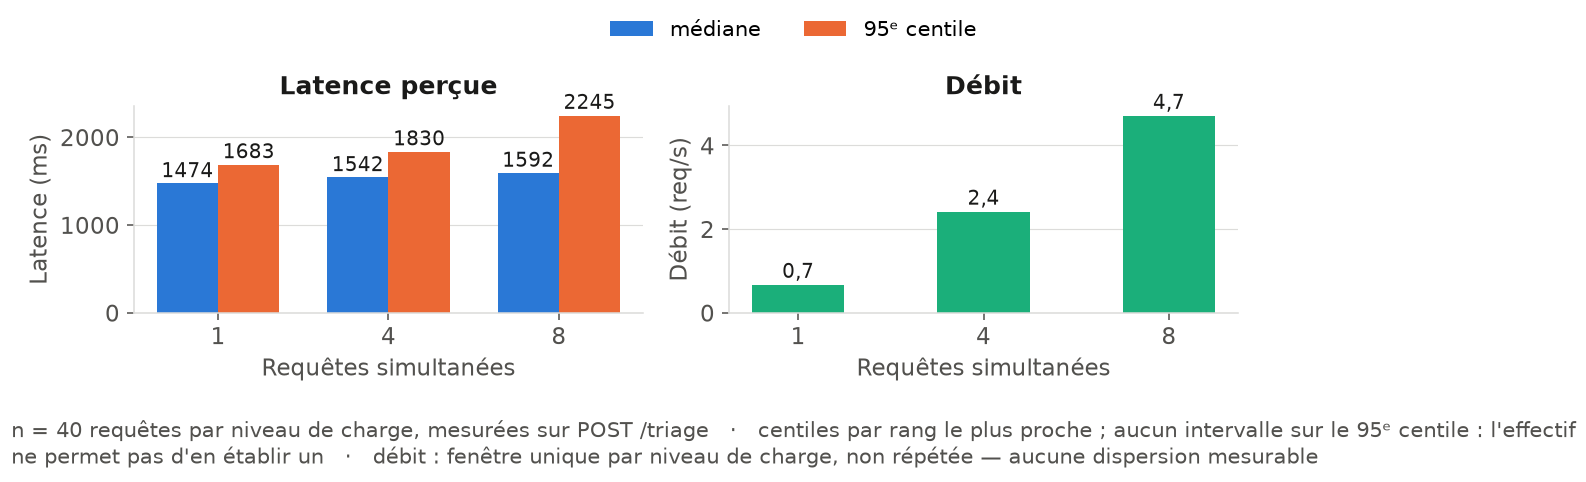

In [13]:
from IPython.display import Image

figure = PATHS.figures / "endpoint_latency.png"
if figure.exists():
    display(Image(str(figure)))

Latencies measured with the development engine are not comparable, and must never be reported
as the endpoint's.

## Where that leaves the service

- The questionnaire **follows the complaint** and stops as soon as a vital sign appears; the
  summary turns every answer into a sentence.
- The triage reply exposes the level, its justification, what to do next, **and the explicit
  rule's verdict**: the disagreement is visible.
- Access is protected by a mandatory key, compared in constant time, with a per-caller quota.
- Every interaction is traced, **masked by the audit module itself**, with the model actually
  loaded.
- The deployment separates the gateway from the model, each updating without the other.

> **What this notebook is.** A teaching demonstration. The triage levels rest on a catalogue
> written for the project and never reviewed by a clinician, and the service is built to sit
> beside a human who decides. Anyone facing a real distress calls the emergency number first.